Con riferimento al data set dell’esercitazione su clustering, eseguire una classificazione 
binaria sulla feature death, una classificazione multiclasse sulla feature dzgroup ed una 
regressione sulla feature aps. 
Di seguito si riportano i passi da seguire separatamente per ciascun task: 
1. Procedere allo split train-test secondo il rapporto 95%-15% in forma stratificata 
secondo i valori della variabile target. 
2. Eseguire l’imputazione dei dati mancanti con le stesse strategie dell’esercitazione 
precedente. 
3. Rimuovere le feature che presentano elevata correlazione con la variabile target e 
successivamente analizzare le possibili feature multicollineari rimanenti. 
4. Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per 
la regressione con i seguenti iperparametri(*) 
a. Classificatore 
i. criterion: “gini”, “log_loss” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
b. Regressore 
i. criterion: “squared_error”, “absolute_error” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
5. Valutare il regressore sul test set con la metrica R2, il classificatore binario con la curva 
ROC e la relativa AUC ed il classificatore multiclasse con le curve ROC e le AUC di ogni 
classe, ciascuna valutata in modalità one-vs-rest. 
(*) Si noti che gli iperparametri indicati potrebbero non essere quelli ottimali perché il 
modello di addestri bene. Opzionalmente si discuta se non sia il caso di condizionare il 
modello ad altri iperparametri e si conducano le relative prove.

In [ ]:
#import dataset
import pandas as pd

df =  pd.read_csv('./dataset_esercitazione.csv')
print(df.shape)

In [ ]:
#split-dataset

from sklearn.model_selection import train_test_split

df.drop( columns=['dzgroup', 'dzclass'], inplace=True)
X = df.drop('death', axis=1)
y = df['death']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [ ]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()

cat_features = [ column  for column in X_train.columns if column not in numeric_features]


import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# 1. IMPUTATION
imputer1 = SimpleImputer(strategy='median').set_output(transform="pandas")
imputer2 = SimpleImputer(strategy='constant', fill_value='Unknown').set_output(transform="pandas")

# Fit e transform separati per tipo
X_tr_num = imputer1.fit_transform(X_train[numeric_features])
X_tr_cat = imputer2.fit_transform(X_train[cat_features])

X_te_num = imputer1.transform(X_test[numeric_features])
X_te_cat = imputer2.transform(X_test[cat_features])

# 2. ENCODING (Solo sulle colonne categoriche!)
encoder = OrdinalEncoder().set_output(transform="pandas")

# Applichiamo l'encoder SOLO ai pezzi categorici già imputati
X_tr_cat_enc = encoder.fit_transform(X_tr_cat)
X_te_cat_enc = encoder.transform(X_te_cat)

# 3. UNIONE FINALE (Numeri originali + Categorie encodate)
X_train_final = pd.concat([X_tr_num, X_tr_cat_enc], axis=1)
X_test_final = pd.concat([X_te_num, X_te_cat_enc], axis=1)

print(X_train_final.head())

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final[numeric_features] = scaler.fit_transform(X_train_final[numeric_features])
X_test_final[numeric_features] = scaler.transform(X_test_final[numeric_features])
print(X_train_final.head())





In [ ]:
#rimozione feature con alta correlazione

# 1. Calcoliamo la matrice (valore assoluto)
corr_matrix = X_train_final.corr().abs()

# 2. Creiamo un set per raccogliere le colonne da eliminare
# (usiamo un set così non aggiungiamo doppioni)
to_drop = set()

# 3. Ciclo for per confrontare ogni coppia di colonne
# i = indice della prima colonna
# j = indice della seconda colonna
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        # Se la correlazione tra la colonna i e la colonna j è > 0.7
        if corr_matrix.iloc[i, j] > 0.7:
            colname = corr_matrix.columns[i] # prendiamo il nome della colonna i
            to_drop.add(colname)

# 4. Trasformiamo il set in lista per poterlo usare nel drop
to_drop = list(to_drop)

print(f"Feature rimosse: {to_drop}")

# 5. Rimuoviamo le colonne
X_train_reduced = X_train_final.drop(columns=to_drop)
X_test_reduced = X_test_final.drop(columns=to_drop)

In [ ]:
print(X_train_reduced.shape, y_train.shape)
print(X_test_reduced.shape, y_test.shape)

4. Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per 
la regressione con i seguenti iperparametri(*) 
a. Classificatore 
i. criterion: “gini”, “log_loss” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
b. Regressore 
i. criterion: “squared_error”, “absolute_error” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

matrix_results_bin = []
models_dict_bin = {} 

for criterio in ['gini', 'log_loss']:
    for min_samples in [2, 5, 10]:
        for max_features in ['sqrt', 5]:
            
            nome_modello = f"Bin_{criterio}_ms{min_samples}_mf{max_features}"
            
            clf = RandomForestClassifier(
                criterion=criterio, 
                min_samples_split=min_samples, 
                max_features=max_features, 
                random_state=42
            )
            
            # Addestramento sul target BINARIO (death)
            model = clf.fit(X_train_reduced, y_train) 
            
            y_pred = model.predict(X_test_reduced)
            y_score = model.predict_proba(X_test_reduced)[:, 1] # Probabilità classe 1
            
            acc = accuracy_score(y_test, y_pred)
            # Per la binaria, l'AUC è più semplice
            auc_val = roc_auc_score(y_test, y_score)
            
            result_entry = {
                'modello': nome_modello,
                'criterio': criterio,
                'min_samples': min_samples,
                'max_features': max_features,
                'accuracy': acc,
                'auc': auc_val
            }
            
            matrix_results_bin.append(result_entry)
            models_dict_bin[nome_modello] = model

df_risultati_bin = pd.DataFrame(matrix_results_bin)
print(df_risultati_bin.sort_values(by='accuracy', ascending=False))
            

                     modello  criterio  min_samples max_features  accuracy  \
10  Bin_log_loss_ms10_mfsqrt  log_loss           10         sqrt  0.785832   
11     Bin_log_loss_ms10_mf5  log_loss           10            5  0.785832   
2        Bin_gini_ms5_mfsqrt      gini            5         sqrt  0.784734   
3           Bin_gini_ms5_mf5      gini            5            5  0.784734   
8    Bin_log_loss_ms5_mfsqrt  log_loss            5         sqrt  0.779242   
9       Bin_log_loss_ms5_mf5  log_loss            5            5  0.779242   
0        Bin_gini_ms2_mfsqrt      gini            2         sqrt  0.778693   
1           Bin_gini_ms2_mf5      gini            2            5  0.778693   
4       Bin_gini_ms10_mfsqrt      gini           10         sqrt  0.778144   
5          Bin_gini_ms10_mf5      gini           10            5  0.778144   
6    Bin_log_loss_ms2_mfsqrt  log_loss            2         sqrt  0.777046   
7       Bin_log_loss_ms2_mf5  log_loss            2            5

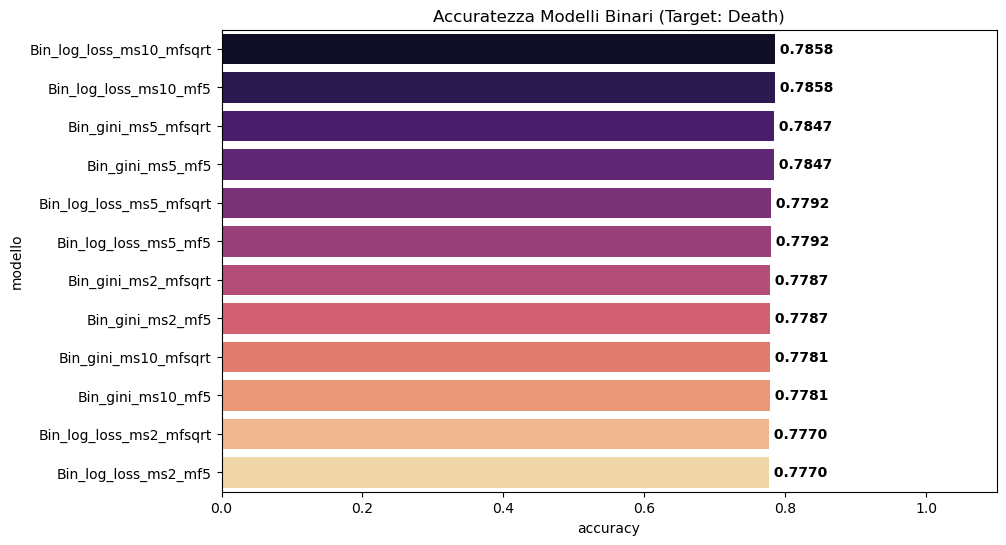


--- Analisi Dettagliata (Miglior Modello: Bin_log_loss_ms10_mfsqrt) ---


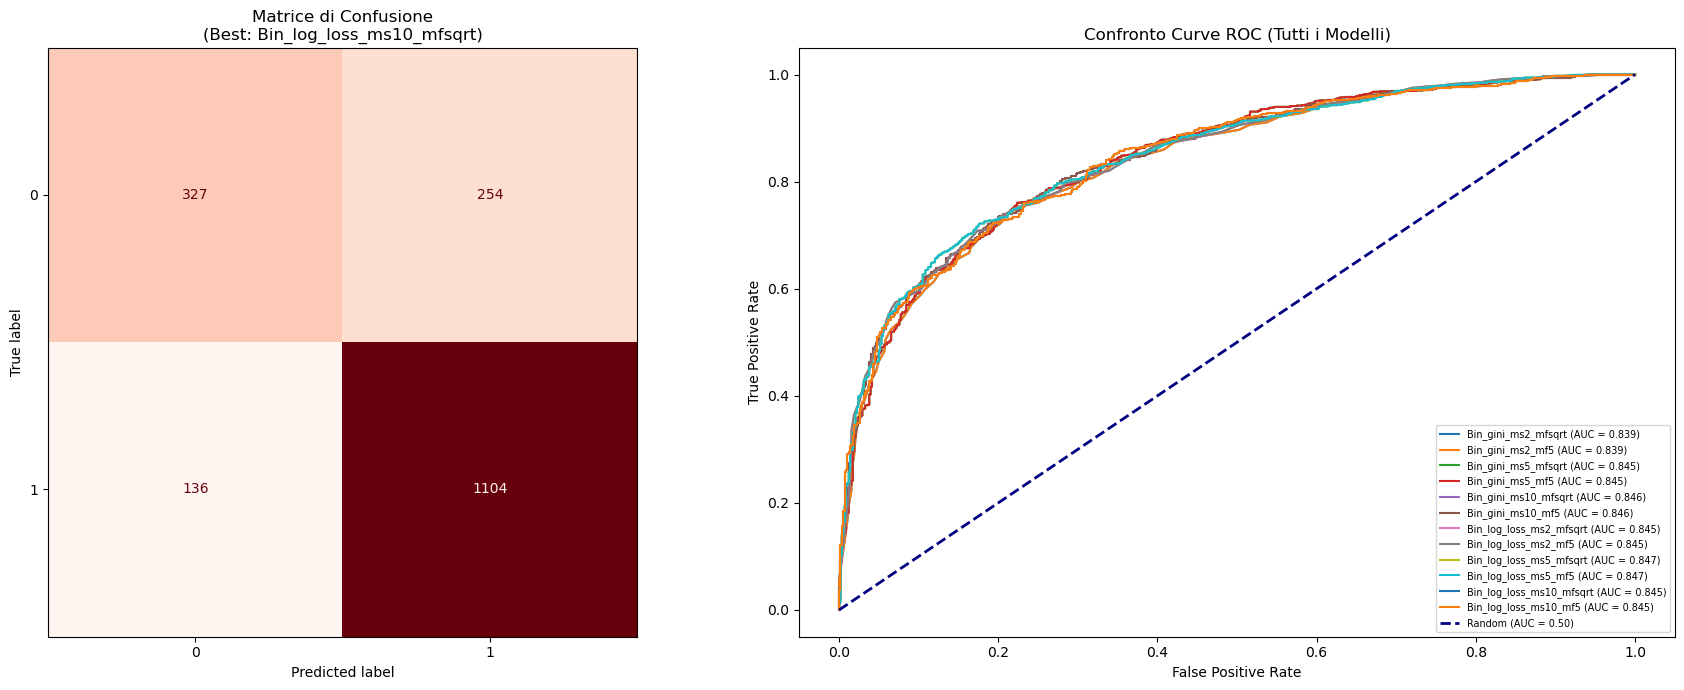

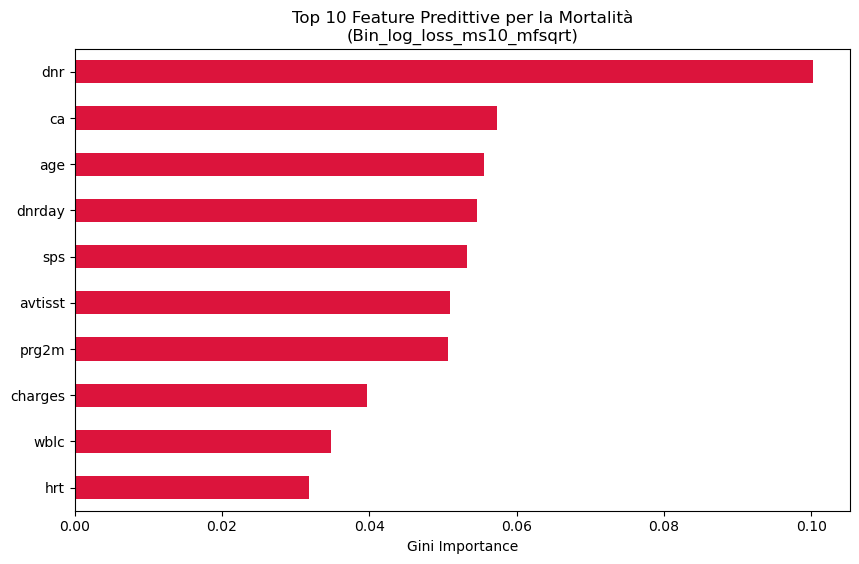

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

def visualizza_risultati_binari(df_risultati, X_test, y_test, modelli_salvati):
    """
    Versione specifica per classificazione binaria:
    - Confronto accuratezza modelli
    - Matrice di Confusione del MIGLIORE
    - Curve ROC di TUTTI i modelli per confronto
    - Feature Importance del MIGLIORE
    """
    
    # --- 1. CONFRONTO ACCURATEZZA ---
    plt.figure(figsize=(10, 6))
    df_plot = df_risultati.sort_values('accuracy', ascending=False)
    
    sns.barplot(
        x='accuracy', 
        y='modello', 
        data=df_plot, 
        hue='modello', 
        palette='magma', 
        legend=False
    )
    plt.title('Accuratezza Modelli Binari (Target: Death)')
    plt.xlim(0, 1.1)
    for i, val in enumerate(df_plot['accuracy']):
        plt.text(val, i, f' {val:.4f}', va='center', fontweight='bold')
    plt.show()

    # --- IDENTIFICAZIONE MIGLIOR MODELLO ---
    best_model_name = df_plot.iloc[0]['modello']
    best_clf = modelli_salvati[best_model_name]
    y_pred_best = best_clf.predict(X_test)
    
    print(f"\n--- Analisi Dettagliata (Miglior Modello: {best_model_name}) ---")

    # --- 2 & 3. MATRICE DI CONFUSIONE (Migliore) E TUTTE LE CURVE ROC ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # A. Matrice di Confusione (Solo del migliore per non fare confusione)
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred_best, 
        cmap='Reds', 
        ax=ax1,
        colorbar=False
    )
    ax1.set_title(f"Matrice di Confusione\n(Best: {best_model_name})")

    # B. Curve ROC di TUTTI i modelli
    for nome_modello, clf in modelli_salvati.items():
        y_score = clf.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        ax2.plot(fpr, tpr, lw=1.5, label=f'{nome_modello} (AUC = {roc_auc:.3f})')
    
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.50)')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('Confronto Curve ROC (Tutti i Modelli)')
    # Spostiamo la legenda fuori se sono troppi modelli
    ax2.legend(loc="lower right", fontsize='x-small', ncol=1) 
    
    plt.tight_layout()
    plt.show()

    # --- 4. FEATURE IMPORTANCE BINARIA (Migliore) ---
    plt.figure(figsize=(10, 6))
    importances = best_clf.feature_importances_
    feat_importances = pd.Series(importances, index=X_test.columns).sort_values(ascending=True).tail(10)
    
    feat_importances.plot(kind='barh', color='crimson')
    plt.title(f"Top 10 Feature Predittive per la Mortalità\n({best_model_name})")
    plt.xlabel("Gini Importance")
    plt.show()

# --- CHIAMATA ---
# Assicurati che y_test sia quello relativo a 'death'
visualizza_risultati_binari(df_risultati_bin, X_test_reduced, y_test, models_dict_bin)